## Table of Contents
1. [Introduction](#introduction)
2. [Setup and Imports](#setup)
3. [Loading the Fashion MNIST Dataset](#load)
4. [Data Exploration & Visualization](#explore)
5. [Data Preprocessing](#preprocess)
6. [Model Building (DNN)](#dnn)
7. [Training the Model](#train)
8. [Performance Visualization](#visual)
9. [Predictions & Confusion Matrix](#predict)
10. [Making Predictions on New Images](#inference)
11. [Saving the Trained Model](#save-model)
12. [Loading a Pretrained Model](#load-model)

## 1. Introduction

In this section, we will introduce the **Fashion MNIST dataset** and the goal of this notebook, which is to build and train a **Deep Learning model** using TensorFlow/Keras to classify fashion items.

---

### 1.1 What is the Fashion MNIST Dataset?

The **Fashion MNIST** dataset is a collection of **60,000 training** and **10,000 test** images of fashion items, such as clothing and accessories. Each image is **28x28 pixels** in grayscale, and the dataset consists of **10 classes**, including items like T-shirts, dresses, and sneakers.

---

### 1.2 Dataset Structure

The dataset consists of the following:
- **Training set**: 60,000 grayscale images (28x28 pixels)
- **Test set**: 10,000 images used for evaluating the trained model.

Each image belongs to one of the following 10 classes:
1. T-shirt/top
2. Trouser
3. Pullover
4. Dress
5. Coat
6. Sandal
7. Shirt
8. Sneaker
9. Bag
10. Ankle boot

---

### 1.3 Goal of this Notebook

The objective of this notebook is to:
1. **Preprocess** the Fashion MNIST dataset by normalizing and reshaping the images.
2. **Build and train** a deep learning model (fully connected neural network).
3. **Evaluate** the model's performance on the test set.
4. **Make predictions** on new, unseen images.
5. **Save and load** the trained model for future use.

## 2. Setup and Imports

In [2]:
# Core libraries for data manipulation and visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Evaluation and splitting tools
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully ")

TensorFlow version: 2.20.0
All libraries imported successfully 


---

# 3. Loading the Fashion MNIST Dataset

In [3]:
# Load Fashion MNIST directly from Keras
fashion_mnist = keras.datasets.fashion_mnist
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

# Define the class names for all 10 categories
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Dataset loaded successfully ")
print(f"Training set shape : {x_train_full.shape}")
print(f"Test set shape     : {x_test.shape}")
print(f"Number of classes  : {len(class_names)}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully 
Training set shape : (60000, 28, 28)
Test set shape     : (10000, 28, 28)
Number of classes  : 10


In [ ]:
!git add .
!git commit -m "Lenah - Sections 1, 2, 3 done"
!git push

[main 5d54cb6] Lenah - Sections 1, 2, 3 done
 1 file changed, 231 insertions(+), 4 deletions(-)


To https://github.com/lenahmahmoud/Neural_Task.git
   625803c..5d54cb6  main -> main


In [ ]:
#check
class_names[1]

'Trouser'

# 4. Data Exploration & Visualization

### 4.1 Dataset Shape and Basic Information

In [4]:
print("Training data shape :", x_train_full.shape)
print("Test data shape     :", x_test.shape)
print("Training labels     :", y_train_full.shape)
print("Test labels         :", y_test.shape)

unique_classes = np.unique(y_train_full)
print("\nNumber of classes:", len(unique_classes))
print("Class labels      :", unique_classes)
print('----------------------------------------')
print('X Train sample  is :', x_train_full[5])
print('----------------------------------------')
print('X Test  sample  is :', x_test[5])
print('----------------------------------------')

Training data shape : (60000, 28, 28)
Test data shape     : (10000, 28, 28)
Training labels     : (60000,)
Test labels         : (10000,)

Number of classes: 10
Class labels      : [0 1 2 3 4 5 6 7 8 9]
----------------------------------------
X Train sample  is : [[  0   0   0   0   1   0   0   0   0  22  88 188 172 132 125 141 199 143
    9   0   0   0   1   0   0   0   0   0]
 [  0   0   0   1   0   0  20 131 199 206 196 202 242 255 255 250 222 197
  206 188 126  17   0   0   0   0   0   0]
 [  0   0   0   1   0  35 214 191 183 178 175 168 150 162 159 152 158 179
  183 189 195 185  82   0   0   0   0   0]
 [  0   0   0   0   0 170 190 172 177 176 171 169 162 155 148 154 169 174
  175 175 177 183 188  12   0   0   0   0]
 [  0   0   0   0  25 194 180 178 174 184 187 189 187 184 181 189 200 197
  193 190 178 175 194  90   0   0   0   0]
 [  0   0   0   0  42 218 191 197 208 204 211 209 210 212 211 214 215 213
  214 211 211 191 200 158   0   0   0   0]
 [  0   0   0   0  88 221 215 217

### 4.2 Sample Images

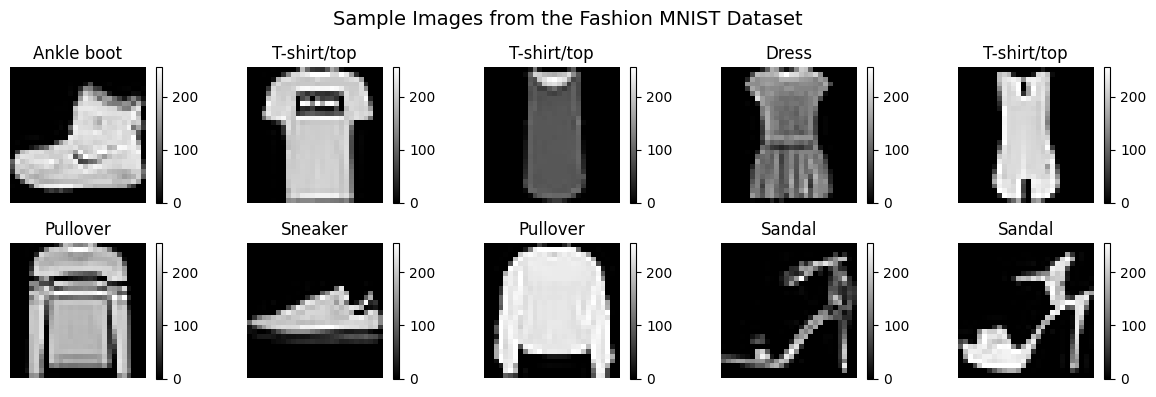

In [5]:
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_full[i], cmap='gray')
    plt.colorbar()
    plt.title(class_names[y_train_full[i]])
    plt.axis('off')
plt.suptitle("Sample Images from the Fashion MNIST Dataset", fontsize=14)
plt.tight_layout()
plt.show()

### 4.3 Class Distribution

#### — Bar Chart

/tmp/ipykernel_11971/2079908105.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_full, palette="Set2")


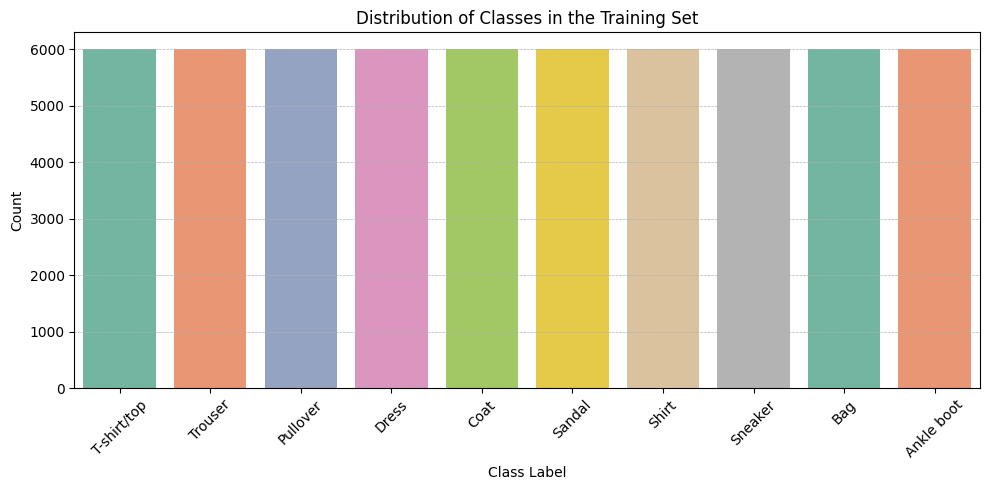

In [6]:
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train_full, palette="Set2")
plt.title("Distribution of Classes in the Training Set")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.xticks(ticks=np.arange(10), labels=class_names, rotation=45)
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

#### — Pie Chart

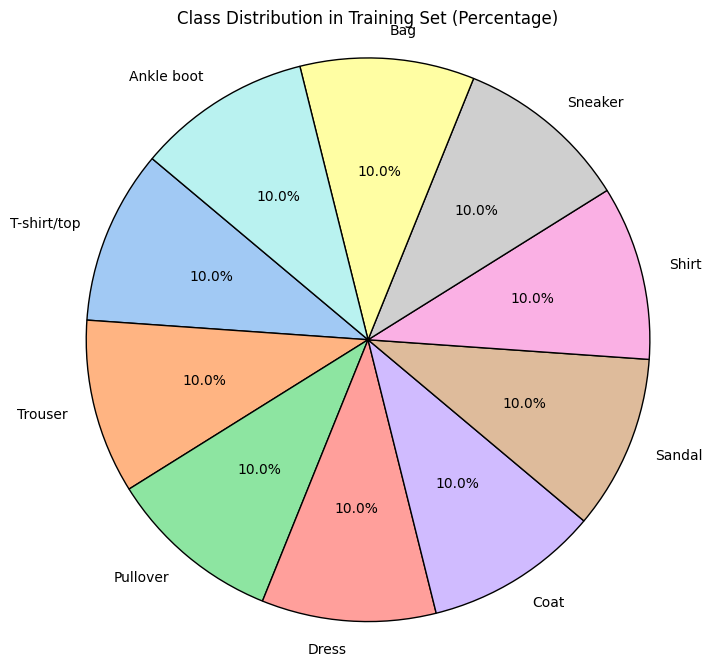

In [7]:

class_counts = np.bincount(y_train_full)


plt.figure(figsize=(8, 8))
plt.pie(class_counts,
        labels=class_names,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'),
        wedgeprops={'edgecolor': 'black'})
plt.title("Class Distribution in Training Set (Percentage)", loc='center')
plt.axis('equal')
plt.show()

# 5. Data Preprocessing

## 5.1 Before Normalization

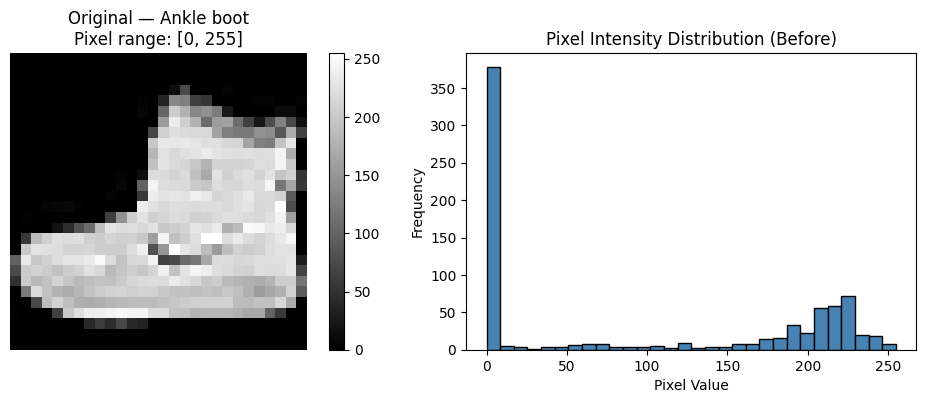

In [9]:
sample_idx = 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Original image
im = ax1.imshow(x_train_full[sample_idx], cmap='gray')
ax1.set_title(f"Original — {class_names[y_train_full[sample_idx]]}\nPixel range: [0, 255]")
ax1.axis('off')
plt.colorbar(im, ax=ax1)

# Pixel histogram
ax2.hist(x_train_full[sample_idx].flatten(), bins=30, color='steelblue', edgecolor='black')
ax2.set_title("Pixel Intensity Distribution (Before)")
ax2.set_xlabel("Pixel Value")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Raw pixel values of first training image:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0 

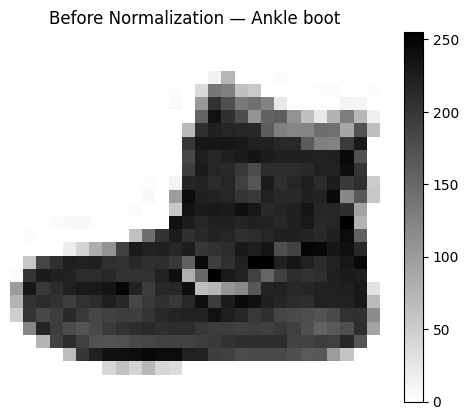

In [10]:
# Keep a raw copy BEFORE normalization for display
x_sample_raw = x_train_full[0].copy()

print('Raw pixel values of first training image:')
print(x_sample_raw)



plt.imshow(x_sample_raw, cmap=plt.cm.binary)
plt.colorbar()
plt.axis('off')
plt.title(f'Before Normalization — {class_names[y_train_full[0]]}')
plt.show()

### 5.2 Normalize Pixel Values

-  **Normalization Formula:**

To scale pixel values to the range $[0, 1]$, we apply **Min-Max Normalization**:

$$
x_{\text{normalized}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

For Fashion MNIST, where pixel values range from 0 to 255, this simplifies to:

$$
x_{\text{normalized}} = \frac{x}{255}
$$

In [11]:
# Normalize pixel values to [0, 1]
x_train_full = x_train_full / 255.0
x_test       = x_test       / 255.0

print('Pixel value range after normalization — min:', x_train_full.min(), '| max:', x_train_full.max())

Pixel value range after normalization — min: 0.0 | max: 1.0


### 5.3 After Normalization

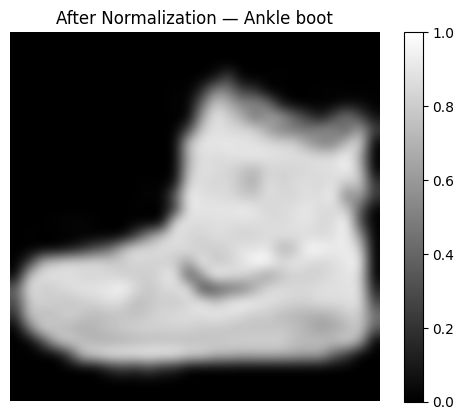

In [13]:
plt.imshow(x_train_full[0], cmap='gray', interpolation='bicubic')
plt.colorbar()
plt.axis('off')
plt.title(f'After Normalization — {class_names[y_train_full[0]]}')
plt.show()

# 6. Data Splitting

We split the original 60,000 training samples into:
- **Training set**:   80% → 48,000 samples
- **Validation set**: 20% → 12,000 samples
- **Test set**: 10,000 samples (already separated by Keras)

> `stratify=y` ensures every class is represented equally in both splits.

##

In [14]:
# Split training data into train and validation sets
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full   # Preserve class proportions in both sets
)

print('Training set shape   :', x_train.shape)
print('Validation set shape :', x_val.shape)
print('Test set shape       :', x_test.shape)

Training set shape   : (48000, 28, 28)
Validation set shape : (12000, 28, 28)
Test set shape       : (10000, 28, 28)


# 7. Model Building (DNN)

We build a **simple fully connected (Dense) neural network** with:
- A `Flatten` input layer to convert 28×28 images into a 1D vector of 784 features.
- Two hidden `Dense` layers with **ReLU** activation.
- `Dropout` layers for regularization to reduce overfitting.
- A final `Dense` output layer with **Softmax** for 10-class classification.

In [15]:
model = tf.keras.models.Sequential(name='FashionMNIST_Classifier')

# Input layer: flatten 28x28 image into a 784-dimensional vector
model.add(tf.keras.layers.Flatten(input_shape=(28, 28), name='Input_Layer'))

# Hidden layer 1: 128 neurons, ReLU activation
model.add(tf.keras.layers.Dense(128, activation='relu', name='Dense_1_ReLU_128'))
model.add(tf.keras.layers.Dropout(0.3, name='Dropout_1'))

# Hidden layer 2: 64 neurons, ReLU activation
model.add(tf.keras.layers.Dense(64, activation='relu', name='Dense_2_ReLU_64'))
model.add(tf.keras.layers.Dropout(0.2, name='Dropout_2'))

# Output layer: 10 neurons (one per class), Softmax activation
model.add(tf.keras.layers.Dense(10, activation='softmax', name='Output_Layer_Softmax'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "FashionMNIST_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (Flatten)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1_ReLU_128 (Dense)        │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2_ReLU_64 (Dense)         │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer_Softmax (Dense)    │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

# 8. Training the Model

In [16]:
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7618 - loss: 0.6781 - val_accuracy: 0.8359 - val_loss: 0.4422
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8309 - loss: 0.4702 - val_accuracy: 0.8587 - val_loss: 0.3891
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8465 - loss: 0.4291 - val_accuracy: 0.8648 - val_loss: 0.3706
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8532 - loss: 0.4029 - val_accuracy: 0.8733 - val_loss: 0.3522
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8598 - loss: 0.3853 - val_accuracy: 0.8798 - val_loss: 0.3394
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8659 - loss: 0.3714 - val_accuracy: 0.8796 - val_loss: 0.3333
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8689 - loss: 0.3608 - val_accuracy: 0.8748 - val_loss: 0.3429
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8714 - loss: 0.3525 - val_accuracy: 0.

In [17]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)
print('Test loss    :', test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8741 - loss: 0.3531
Test accuracy: 0.8741000294685364
Test loss    : 0.353143572807312
